In [2]:
# temporary imports (should be included in next image iteration)
!pip install matplotlib
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 3.0 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 3.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 3.4 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 3.5 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [3]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import IPython.display as ipd
import essentia
import essentia.standard as es
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


In [4]:
FREESOUND_STORE_METADATA_FIELDS = ['id', 'name', 'username', 'previews', 'license', 'tags']

In [5]:
FREESOUND_API_KEY = ""
with open("../fsk.env", "r") as f:
    FREESOUND_API_KEY = f.read().split("=")[1]
    FREESOUND_API_KEY = FREESOUND_API_KEY.replace("\n", "").replace('"','')

client = freesound.FreesoundClient()
client.set_token(FREESOUND_API_KEY)

In [6]:
from helpers import (
    query_freesound,
    retrieve_sound_preview,
    sounds_to_dataframe,
    delete_dataset_with_gc,
    detect_onsets,
    plot_waveform_with_onsets
)

In [7]:
AUDIO_DIR = "../data/audio/"
META_DIR = "../data/meta/"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

In [34]:
# Queries for THIS RUN
freesound_queries = [
    {
        "query": "fireworks",
        "filter": None,
        "num_results": 20,
    },
]

In [35]:
# ACTUAL QUERY SCRIPT
# Timestamp to uniquely identify this run
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
meta_csv_path = os.path.join(META_DIR, f"dataset_{timestamp}.csv")
meta_json_path = os.path.join(META_DIR, f"dataset_{timestamp}.json")

# --------------------------------------------------
# Run queries
# --------------------------------------------------
sounds = []
for q in freesound_queries:
    sounds.extend(
        query_freesound(
            query=q["query"],
            filter=q["filter"],
            client=client,
            fs_store_metadata_fields=FREESOUND_STORE_METADATA_FIELDS,
            num_results=q["num_results"],
        )
    )

print(f"Retrieved {len(sounds)} sound metadata objects")

# --------------------------------------------------
# Download previews (idempotent)
# --------------------------------------------------
for i, sound in enumerate(sounds, 1):
    print(f"[{i}/{len(sounds)}] Downloading sound ID {sound.id}")
    retrieve_sound_preview(client, sound, AUDIO_DIR)

# --------------------------------------------------
# Save metadata for THIS RUN ONLY
# --------------------------------------------------
df = sounds_to_dataframe(sounds, AUDIO_DIR)
df.to_csv(meta_csv_path, index=False)
print(f"Saved metadata CSV: {meta_csv_path}")

# --------------------------------------------------
# Save query log
# --------------------------------------------------
query_log = {
    "timestamp": timestamp,
    "num_sounds": len(sounds),
    "queries": freesound_queries,
}

with open(meta_json_path, "w") as f:
    json.dump(query_log, f, indent=2)

print(f"Saved query log JSON: {meta_json_path}")

Retrieved 20 sound metadata objects
[1/20] Downloading sound ID 349822
File ../data/audio/349822_1857065-hq.ogg already downloaded.
[2/20] Downloading sound ID 46323
File ../data/audio/46323_180659-hq.ogg already downloaded.
[3/20] Downloading sound ID 840900
File ../data/audio/840900_1648170-hq.ogg already downloaded.
[4/20] Downloading sound ID 675777
File ../data/audio/675777_2524442-hq.ogg already downloaded.
[5/20] Downloading sound ID 119650
File ../data/audio/119650_2085904-hq.ogg already downloaded.
[6/20] Downloading sound ID 434402
File ../data/audio/434402_3045606-hq.ogg already downloaded.
[7/20] Downloading sound ID 815445
File ../data/audio/815445_6951162-hq.ogg already downloaded.
[8/20] Downloading sound ID 368417
File ../data/audio/368417_97763-hq.ogg already downloaded.
[9/20] Downloading sound ID 190698
File ../data/audio/190698_1469582-hq.ogg already downloaded.
[10/20] Downloading sound ID 62548
File ../data/audio/62548_446095-hq.ogg already downloaded.
[11/20] Dow

In [36]:
!ls ../data/meta

dataset_2026-01-12_16-08-56.csv   dataset_2026-01-18_19-30-57.json
dataset_2026-01-12_16-08-56.json  dataset_2026-03-18_18-32-10.csv
dataset_2026-01-18_13-58-47.csv   dataset_2026-03-18_18-32-10.json
dataset_2026-01-18_13-58-47.json  dataset_2026-03-18_18-35-35.csv
dataset_2026-01-18_19-06-29.csv   dataset_2026-03-18_18-35-35.json
dataset_2026-01-18_19-06-29.json  dataset_2026-03-18_18-36-36.csv
dataset_2026-01-18_19-30-57.csv   dataset_2026-03-18_18-36-36.json


In [78]:
delete_dataset_with_gc(META_DIR + "dataset_2026-01-18_18-29-36.csv", META_DIR, AUDIO_DIR, dry_run=False)

Deleted metadata file: /workspace/data/meta/dataset_2026-01-18_18-29-36.csv
Deleted query file: /workspace/data/meta/dataset_2026-01-18_18-29-36.json
Deleted audio: /workspace/data/audio/540002_11959822-hq.ogg
Deleted audio: /workspace/data/audio/343168_6071037-hq.ogg
Deleted audio: /workspace/data/audio/514404_1738686-hq.ogg
Deleted audio: /workspace/data/audio/392116_245603-hq.ogg
Deleted audio: /workspace/data/audio/337575_1490240-hq.ogg
Deleted audio: /workspace/data/audio/353692_1431924-hq.ogg
Deleted audio: /workspace/data/audio/772883_6753194-hq.ogg
Deleted audio: /workspace/data/audio/485041_9453283-hq.ogg
Deleted audio: /workspace/data/audio/722412_1490240-hq.ogg
Deleted audio: /workspace/data/audio/244231_4463962-hq.ogg
Deleted audio: /workspace/data/audio/823211_17278148-hq.ogg
Deleted audio: /workspace/data/audio/238919_3406193-hq.ogg
Deleted audio: /workspace/data/audio/267221_3112522-hq.ogg
Deleted audio: /workspace/data/audio/424845_8508138-hq.ogg
Deleted audio: /workspa

### Show downloaded audio

In [41]:
!ls -lt ../data/audio | head -20

total 12472
-rw-r--r-- 1 root root 164807 Mar 18 18:35 56579_30817-hq.ogg
-rw-r--r-- 1 root root  77552 Mar 18 18:35 334042_4921277-hq.ogg
-rw-r--r-- 1 root root 121191 Mar 18 18:35 434205_2780734-hq.ogg
-rw-r--r-- 1 root root  52990 Mar 18 18:35 616280_12932169-hq.ogg
-rw-r--r-- 1 root root  68996 Mar 18 18:35 251618_4040997-hq.ogg
-rw-r--r-- 1 root root  86031 Mar 18 18:35 624414_6886013-hq.ogg
-rw-r--r-- 1 root root 102827 Mar 18 18:35 25779_15220-hq.ogg
-rw-r--r-- 1 root root 121341 Mar 18 18:35 736641_7966491-hq.ogg
-rw-r--r-- 1 root root  34698 Mar 18 18:35 347117_369949-hq.ogg
-rw-r--r-- 1 root root  52996 Mar 18 18:35 453104_612689-hq.ogg
-rw-r--r-- 1 root root  26360 Mar 18 18:35 62548_446095-hq.ogg
-rw-r--r-- 1 root root 104786 Mar 18 18:35 190698_1469582-hq.ogg
-rw-r--r-- 1 root root  93940 Mar 18 18:35 368417_97763-hq.ogg
-rw-r--r-- 1 root root 178742 Mar 18 18:35 815445_6951162-hq.ogg
-rw-r--r-- 1 root root 161308 Mar 18 18:35 434402_3045606-hq.ogg
-rw-r--r-- 1 root root 1

In [46]:
# select a file manually
filename = "434205_2780734-hq.ogg"
filename = AUDIO_DIR + filename
filename

'../data/audio/434205_2780734-hq.ogg'

In [29]:
# select a file randomly
filename = random.choice(os.listdir(AUDIO_DIR))
filename = AUDIO_DIR + filename
filename

'../data/audio/444372_4636389-hq.ogg'

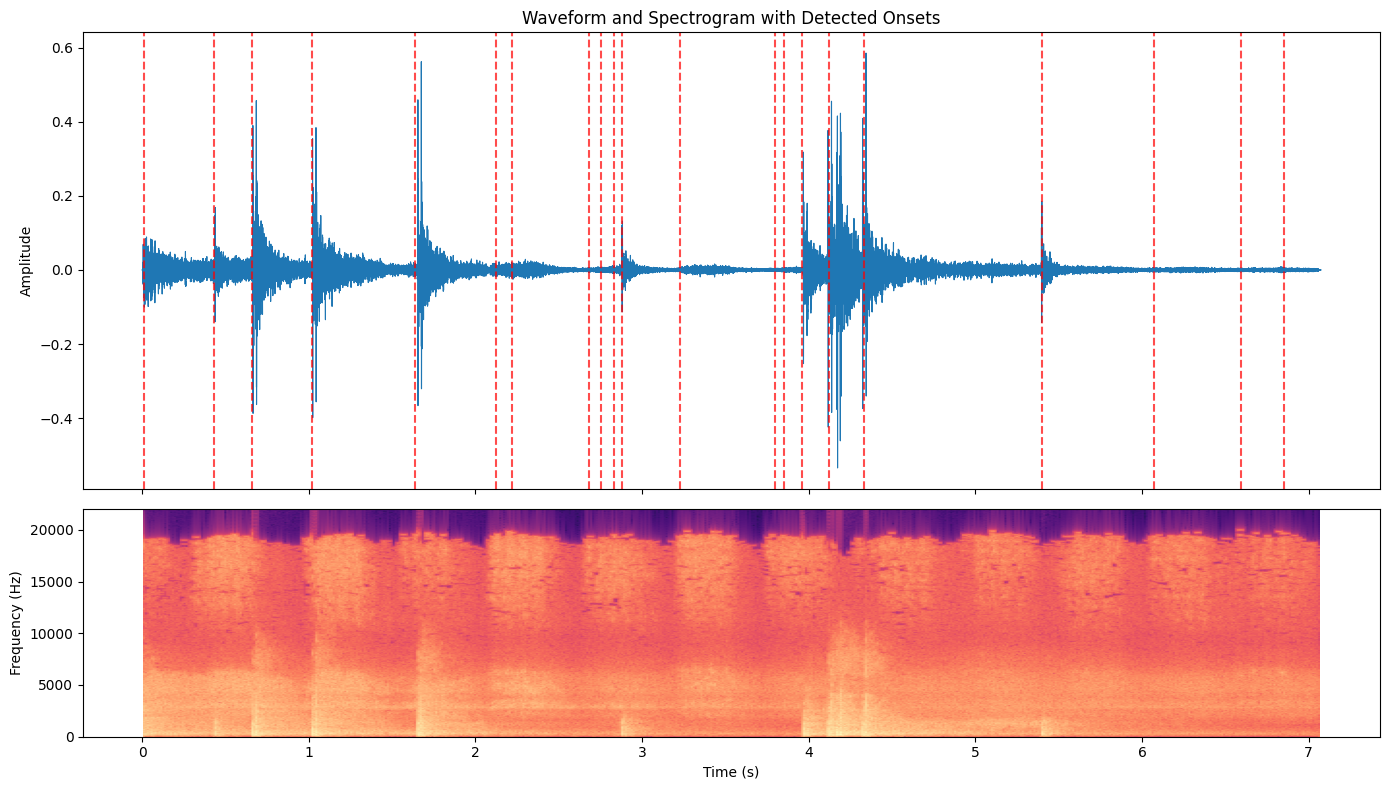

In [47]:
start_time = None
end_time = None
sr = 44100

audio, onset_times = detect_onsets(filename)

plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=sr,
    start_time=start_time,
    end_time=end_time
)

# Audio playback
start_sample = int(start_time * sr) if start_time else 0
end_sample = int(end_time * sr) if end_time else len(audio)-1

ipd.Audio(audio[start_sample:end_sample], rate=sr)